# Análisis exploratorio de variables clínicas y mutacionales asociadas a la clasificación histológica (LGG vs. GBM)

## Dataset

El conjunto de datos utilizado para el análisis es `TCGA_InfoWithGrade.csv`,
correspondiente a una versión preprocesada de los datos relacionados con
gliomas del proyecto The Cancer Genome Atlas (TCGA).

In [1]:
#| echo: false
# Configuracion visual

sns.set_theme(context="notebook", style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "0.3",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.frameon": False,
    "figure.facecolor": "white",
})

PALETTE_GRADE = {0: "#2E86AB", 1: "#C1443C"}
PALETTE_SEQ   = sns.color_palette("mako", as_cmap=False)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

NameError: name 'sns' is not defined

In [174]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency, ttest_ind
import io
import base64
from IPython.display import display, HTML



# Dataset
df_mutations = pd.read_csv("dataset/TCGA_InfoWithGrade.csv")
df_mutations.head()

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [172]:
df_mutations.tail()

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
834,1,1,77.89,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
835,1,0,85.18,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
836,1,1,77.49,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
837,1,0,63.33,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
838,1,0,76.61,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Variable objetivo

- **`Grade`**: indica el grado del glioma. Esta variable distingue entre
  los dos grupos principales presentes en el conjunto de datos:
  `LGG` (*Low-Grade Glioma*) y `GBM` (*Glioblastoma Multiforme*).

## Variables clínicas

Las variables clínicas proporcionan información sobre las características
demográficas de los pacientes:

- **`Gender`**: género del paciente.
- **`Age_at_diagnosis`**: edad del paciente al momento del diagnóstico.
- **`Race`**: raza reportada del paciente.


## Variables genéticas

El conjunto de datos también contiene variables correspondientes a
diferentes genes. Estas variables están codificadas de forma binaria,
indicando con un valor de **1** la presencia de una mutación en el gen
correspondiente, y con un **0** la ausencia de dicha mutación.


Entre los genes incluidos se encuentran:

- **`IDH1`**: codifica una enzima involucrada en el metabolismo celular.

- **`TP53`**: gen supresor tumoral que participa en el control del ciclo
  celular y en la respuesta al daño del ADN. Sus alteraciones pueden
  favorecer la proliferación de células tumorales.

- **`ATRX`**: participa en el mantenimiento de la estructura de la
  cromatina y en la estabilidad del genoma.

- **`PTEN`**: gen supresor tumoral que regula vías relacionadas con el
  crecimiento y la supervivencia celular.

- **`EGFR`**: codifica un receptor involucrado en señales de crecimiento
  y proliferación celular.

- **`CIC`**: participa en la regulación de la expresión de otros genes y
  en procesos relacionados con el desarrollo celular.

- **`MUC16`**: codifica una proteína de gran tamaño asociada a la
  superficie celular.

- **`PIK3CA`**: participa en la vía de señalización PI3K/AKT, relacionada
  con crecimiento, supervivencia y proliferación celular.

- **`NF1`**: actúa como regulador negativo de señales relacionadas con el
  crecimiento celular. Sus alteraciones pueden contribuir a la
  proliferación tumoral.

- **`PIK3R1`**: codifica una subunidad reguladora de la vía PI3K, que
  interviene en procesos de crecimiento y supervivencia celular.

- **`FUBP1`**: participa en la regulación de la expresión génica y del
  crecimiento celular.

- **`RB1`**: gen supresor tumoral que participa en el control del ciclo
  celular y regula la progresión de las células hacia la división.

- **`NOTCH1`**: forma parte de la vía de señalización Notch, relacionada
  con la diferenciación, proliferación y supervivencia celular.

- **`BCOR`**: participa en la regulación de la expresión génica mediante
  complejos relacionados con la cromatina.

- **`CSMD3`**: codifica una proteína de gran tamaño y se encuentra entre
  los genes que pueden presentar mutaciones en distintos tumores.

- **`SMARCA4`**: participa en la remodelación de la cromatina y, por
  tanto, en la regulación de la expresión de los genes.

- **`GRIN2A`**: codifica una subunidad de un receptor de glutamato,
  relacionado principalmente con la señalización neuronal.

- **`IDH2`**: codifica una enzima metabólica relacionada con IDH1.

- **`FAT4`**: participa en procesos relacionados con la organización,
  adhesión y crecimiento de las células.

- **`PDGFRA`**: codifica un receptor involucrado en señales de
  crecimiento y proliferación celular.


El dataset está compuesto por 24 variables de las cuales 23 son binarias mientras que `Age_at_diagnosis` es númerica (`float64`), expresando  en años la edad del paciente al momento del diagnóstico, donde la parte
decimal incorpora información adicional sobre los días transcurridos.

El objetivo a resolver es predecir la severidad del glioma en pacientes, clasificándolos entre Glioma de Bajo Grado (**LGG**) y Glioblastoma Multiforme (**GBM**) a partir de sus características clínicas y perfil de mutaciones genéticas. Sin embargo, antes de entrenar modelos de clasificación supervisados y realizar la selección óptima de variables, iniciaremos con un análisis exploratorio de datos (EDA) sobre el conjunto de entrenamiento (Train set) derivado del dataset TCGA Glioma. El propósito es comprender la estructura de las variables, identificar los patrones de mutación genéticos más frecuentes, detectar valores atípicos y analizar las relaciones clave entre los biomarcadores clínicos y las alteraciones moleculares que diferencian ambos tipos de tumor.


## Estructura

In [45]:
info_df = pd.DataFrame({
    "Tipo de dato": df_mutations.dtypes.astype(str),
    "Valores no nulos": df_mutations.notna().sum().values,
    "Valores nulos": df_mutations.isna().sum().values
})

info_df

,Tipo de dato,Valores no nulos,Valores nulos
Grade,int64,839,0
Gender,int64,839,0
Age_at_diagnosis,float64,839,0
Race,int64,839,0
IDH1,int64,839,0
TP53,int64,839,0
ATRX,int64,839,0
PTEN,int64,839,0
EGFR,int64,839,0
CIC,int64,839,0


El conjunto de datos presenta una estructura limpia y estructurada, compuesta por **839 registros y 24 variables**, sin presencia de valores nulos o faltantes. Está conformado por una variable continua de tipo flotante correspondiente a la edad al diagnóstico (`Age_at_diagnosis`) y un conjunto de variables categóricas que incluyen la variable objetivo (`Grade`), características demográficas como género y raza, y la presencia o ausencia de mutaciones en los 20 genes analizados. 

Las variables binarias, originalmente codificadas mediante valores enteros `0` y `1`, fueron transformadas al tipo categórico (`category`) para representar adecuadamente su naturaleza y facilitar su análisis exploratorio. Esta estructura tabular compacta permite realizar de manera eficiente el análisis exploratorio de datos, la visualización de patrones y las posteriores etapas de ingeniería de características y modelado predictivo.

In [46]:
# Conversión de columnas categóricas a tipo "category"

columnas_categoricas = df_mutations.columns.difference(["Age_at_diagnosis"])
df_mutations[columnas_categoricas] = df_mutations[columnas_categoricas].astype("category")

pd.DataFrame({
    "Tipo": df_mutations.dtypes.astype(str)
}).T

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
Tipo,category,category,float64,category,category,category,category,category,category,category,...,category,category,category,category,category,category,category,category,category,category


## Missing data

A continuación se revisan los valores faltantes y las principales
estadísticas descriptivas del conjunto de datos.

In [47]:
print("Valores faltantes:")
display(df_mutations.isnull().sum().sum())

Valores faltantes:


0

El conjunto de datos no presenta datos faltantes.

## División del dataset

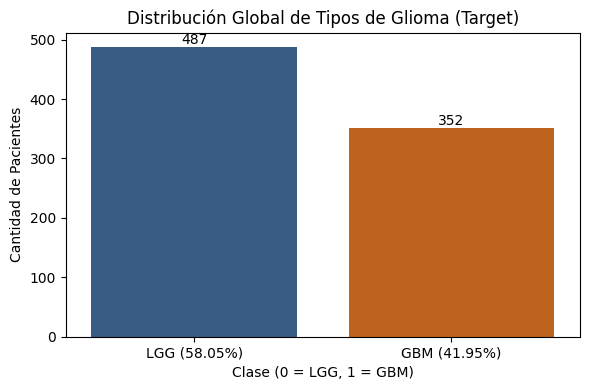

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

conteo = df_mutations['Grade'].value_counts()
proporcion = df_mutations['Grade'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_mutations, x='Grade', palette=['#2b5c8f', '#d95f02'])
plt.title('Distribución Global de Tipos de Glioma (Target)')
plt.xlabel('Clase (0 = LGG, 1 = GBM)')
plt.ylabel('Cantidad de Pacientes')
plt.xticks(ticks=[0, 1], labels=['LGG (58.05%)', 'GBM (41.95%)'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

La elección de una partición estratificada (Stratified Train-Test Split) se justifica por la necesidad de preservar la proporción original de las clases de la variable objetivo (Grade) en ambos subconjuntos de datos. En el dataset completo, la distribución presenta un ligero desbalance, donde el 58.05% corresponde a Gliomas de Bajo Grado (LGG) y el 41.95% a Glioblastomas (GBM), una división sin estratificar podría dejar los conjuntos de `train` y `test` sesgados a un solo grupo de la variable `Grade`.

In [49]:
from sklearn.model_selection import train_test_split

x = df_mutations.drop(columns=['Grade'])
y = df_mutations['Grade']

X_train, X_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

train_data = pd.concat([X_train, y_train], axis=1)

Para asegurar una evaluación rigurosa del modelo y prevenir la fuga de datos, el conjunto original de 839 registros se dividió en una proporción 80/20 mediante una partición estratificada basada en la variable objetivo (`Grade`). De este modo, se reservó un conjunto de prueba (*Test set*) compuesto por 168 pacientes exclusivamente para la validación final del rendimiento, mientras que las 671 observaciones restantes formaron el conjunto de entrenamiento (*Train set*), garantizando que el patrón de distribución de las clases —aproximadamente 58% para tumores de bajo grado (LGG) y 42% para glioblastomas (GBM)— se mantuviera perfectamente balanceado entre ambas subdivisiones.

## Análisis Univariado

### Variable `Grade` (Target)

Resumen estadístico de la variable objetivo:

### Variables cuantitativas

Resumen estadístico de la variable `Age_at_diagnosis`:

### Variables cualitativas

Para las variables categóricas se realizó un análisis univariado basado en sus frecuencias absolutas y relativas. Para cada variable se presenta una tabla con el número de observaciones y el porcentaje correspondiente a cada categoría, acompañada de su respectivo gráfico de barras de frecuencia. Esta representación permite visualizar y comparar la distribución de las categorías, así como identificar aquellas con mayor o menor presencia dentro del conjunto de datos.

#### `Gender`

La distribución por género muestra un ligero predominio de hombres, correspondientes a la categoría `0`, con 398 registros **(59,31 %)**. Por su parte, las mujeres, representadas por la categoría `1`, corresponden a 273 registros **(40,69 %)**.

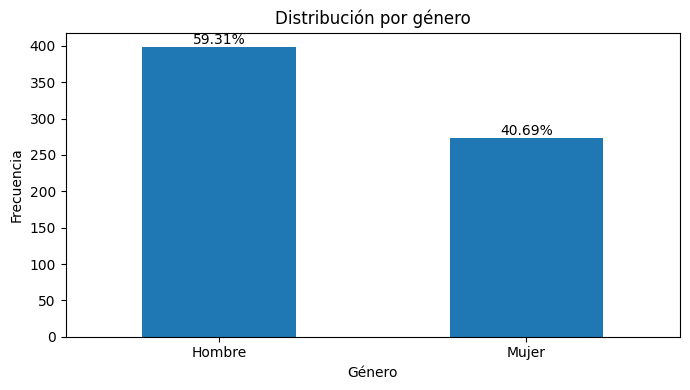

Género,Frecuencia,Porcentaje
Hombre,398,59.31
Mujer,273,40.69


In [108]:
# Tabla
tabla_gender = (
    train_data["Gender"]
    .value_counts()
    .rename_axis("Género")
    .reset_index(name="Frecuencia")
)

tabla_gender["Porcentaje"] = (
    tabla_gender["Frecuencia"] /
    tabla_gender["Frecuencia"].sum() * 100
).round(2)

tabla_gender["Género"] = tabla_gender["Género"].map({
    0: "Hombre",
    1: "Mujer"
})


# Gráfico
frecuencias_gender = (
    train_data["Gender"]
    .value_counts()
    .sort_index()
)

frecuencias_gender.index = ["Hombre", "Mujer"]

plt.figure(figsize=(7, 4))

ax = frecuencias_gender.plot(kind="bar")

plt.title("Distribución por género")
plt.xlabel("Género")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)

for i, porcentaje in enumerate(tabla_gender["Porcentaje"]):
    ax.text(
        i,
        frecuencias_gender.iloc[i] + 5,
        f"{porcentaje:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

tabla_html = tabla_gender.to_html(index=False)

tabla_html = tabla_html.replace(
    "<table",
    '<table style="margin-top: 30px;"'
)

display(HTML(tabla_html))

#### `Race`

En cuanto a la variable `Race`, se observa una marcada concentración de los registros en la categoría **White**, que representa 611 casos **(91,06 %)** del conjunto analizado. La categoría **Black or African American** cuenta con 46 registros **(6,86 %)**, mientras que **Asian** representa 13 casos **(1,94 %)**. Finalmente, **American Indian or Alaska Native** presenta únicamente 1 registro **(0,15 %)**.

La distribución evidencia un fuerte desbalance en la variable racial, dado que la categoría de personas de raza blanca concentra más de nueve de cada diez observaciones. Por tanto, las categorías minoritarias tienen una representación considerablemente menor dentro del conjunto de datos.

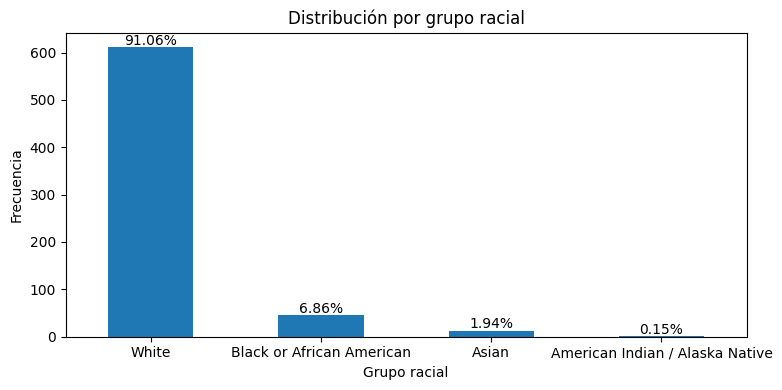

Grupo racial,Frecuencia,Porcentaje
White,611,91.06
Black or African American,46,6.86
Asian,13,1.94
American Indian or Alaska Native,1,0.15


In [109]:
# Tabla
tabla_race = (
    train_data["Race"]
    .value_counts()
    .rename_axis("Grupo racial")
    .reset_index(name="Frecuencia")
)

tabla_race["Porcentaje"] = (
    tabla_race["Frecuencia"] /
    tabla_race["Frecuencia"].sum() * 100
).round(2)

tabla_race["Grupo racial"] = tabla_race["Grupo racial"].map({
    0: "White",
    1: "Black or African American",
    2: "Asian",
    3: "American Indian or Alaska Native"
})


# Gráfico
frecuencias_race = (
    train_data["Race"]
    .value_counts()
    .sort_index()
)

frecuencias_race.index = [
    "White",
    "Black or African American",
    "Asian",
    "American Indian / Alaska Native"
]

plt.figure(figsize=(8, 4))

ax = frecuencias_race.plot(kind="bar")

plt.title("Distribución por grupo racial")
plt.xlabel("Grupo racial")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)

for i, porcentaje in enumerate(tabla_race["Porcentaje"]):
    ax.text(
        i,
        frecuencias_race.iloc[i] + 5,
        f"{porcentaje:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

tabla_html = tabla_race.to_html(index=False)

tabla_html = tabla_html.replace(
    "<table",
    '<table style="margin-top: 30px;"'
)

display(HTML(tabla_html))

#### `Variables genéticas`

Las variables genéticas presentan una distribución predominantemente concentrada en la categoría `0`, correspondiente a la ausencia de mutación, mientras que la categoría `1` representa su presencia. 

Entre los genes analizados, **IDH1** presenta la mayor proporción de casos con mutación, con 322 registros **(47,99 %)**, seguido de **TP53**, con 270 registros **(40,24 %)**. A continuación se encuentran **ATRX** con **25,63 %**, **PTEN** con **16,84 %**, **CIC** con **13,71 %**, **EGFR** con **11,62 %** y **MUC16** con **11,03 %**. En un nivel intermedio se encuentran **PIK3CA (8,49 %)**, **NF1 (8,35 %)** y **FUBP1 (6,26 %)**, mientras que **PIK3R1 (5,81 %)**, **RB1 (4,92 %)** y **NOTCH1 (4,92 %)** presentan proporciones inferiores al 6 %. Finalmente, genes como **CSMD3 (3,43 %)**, **SMARCA4 (3,43 %)**, **IDH2 (3,13 %)**, **BCOR (3,28 %)**, **GRIN2A (2,83 %)**, **FAT4 (2,68 %)** y **PDGFRA (2,68 %)** muestran una presencia de mutaciones relativamente baja en el conjunto analizado. 

En términos generales, se observa una alta variabilidad en la frecuencia de las mutaciones entre los genes, con una mayor concentración en IDH1 y TP53 y una presencia considerablemente menor en los genes restantes. Esto evidencia que las alteraciones genéticas no se distribuyen de manera uniforme en la muestra y que algunos genes presentan una representación mutacional mucho mayor que otros.

Categoría,Frecuencia,Porcentaje
0,349,52.01
1,322,47.99
Categoría,Frecuencia,Porcentaje
0,401,59.76
1,270,40.24
Categoría,Frecuencia,Porcentaje
0,499,74.37
1,172,25.63
Categoría,Frecuencia,Porcentaje
0,558,83.16

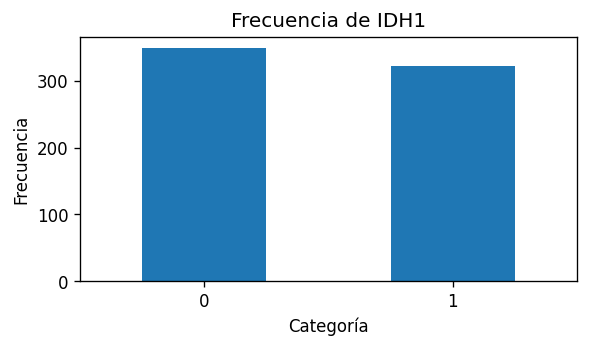
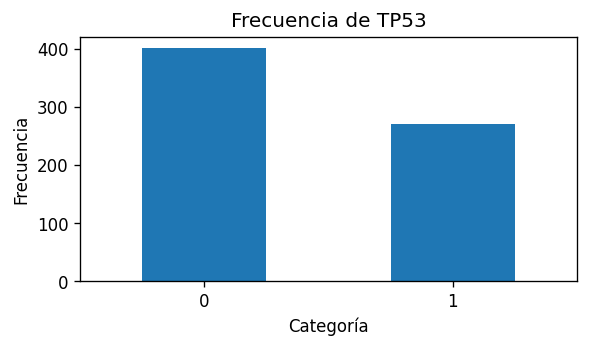
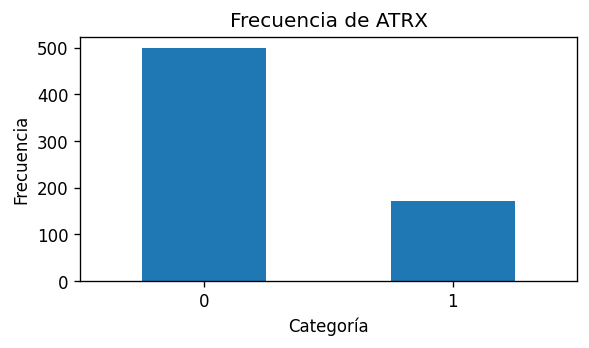
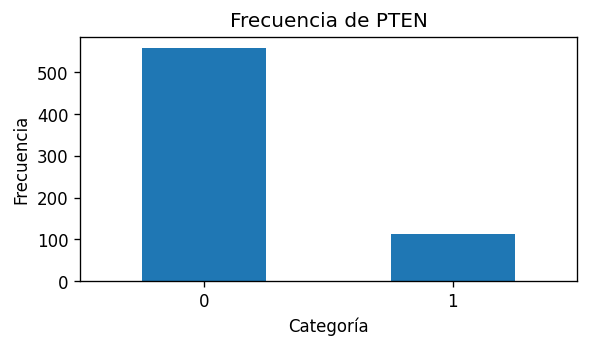
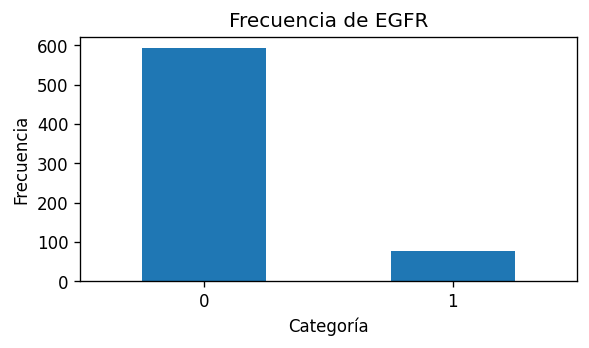
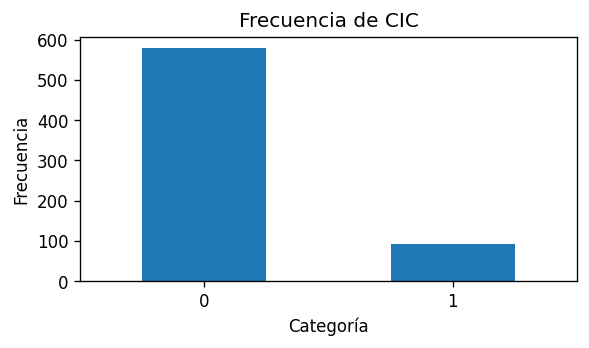
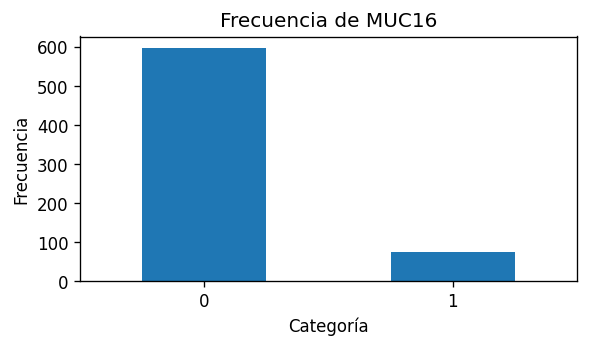
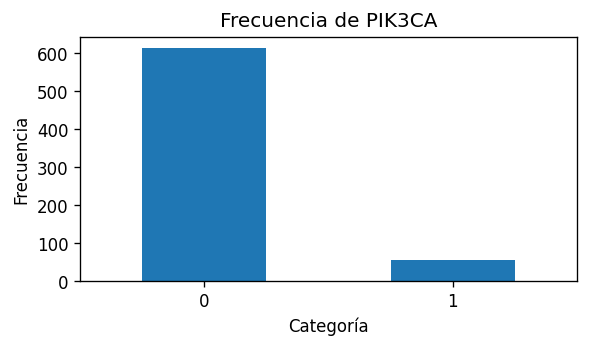
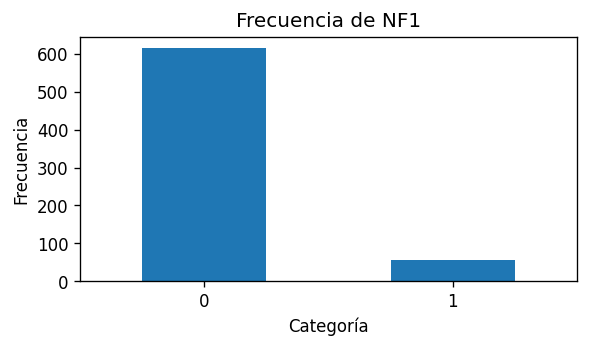
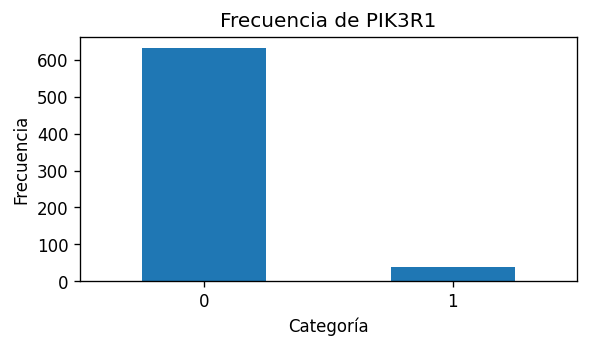
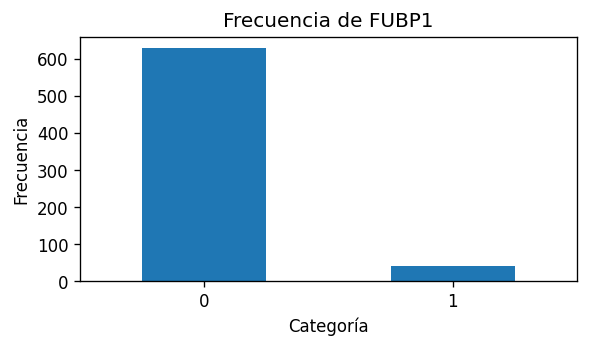
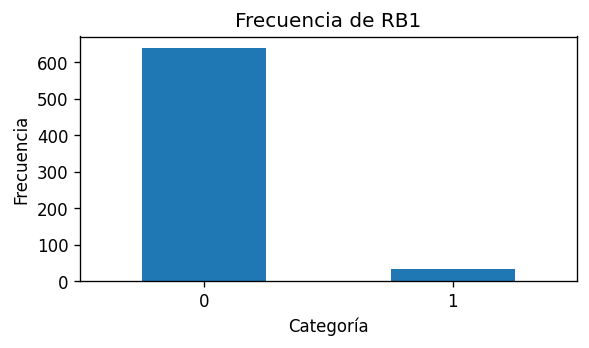
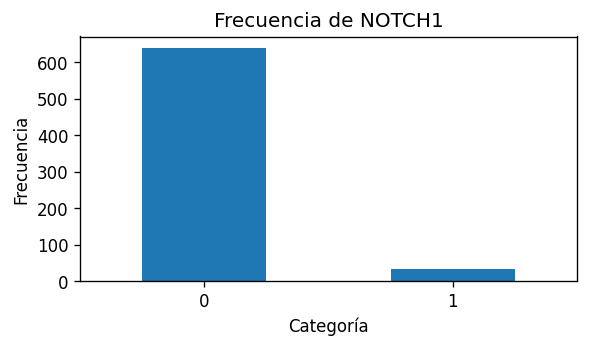
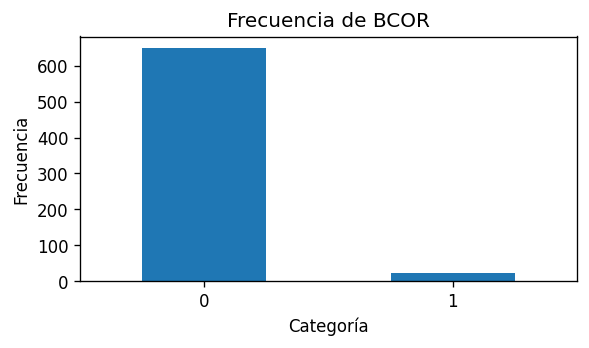
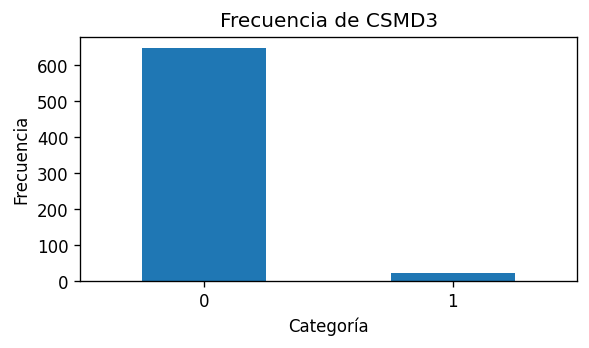
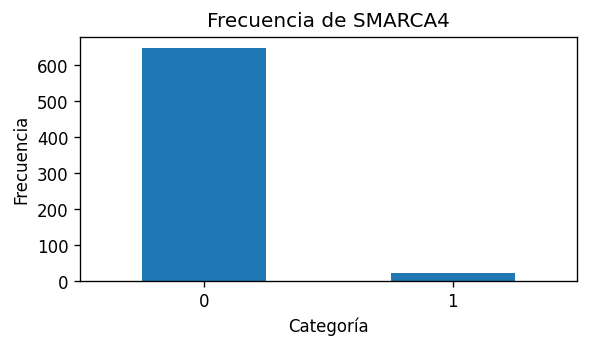
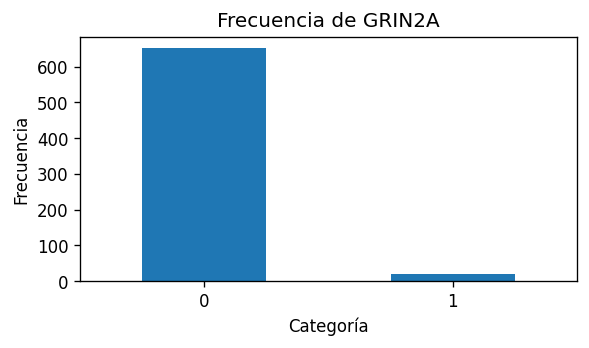
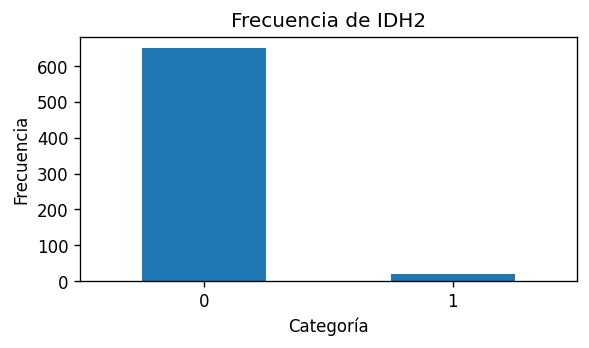
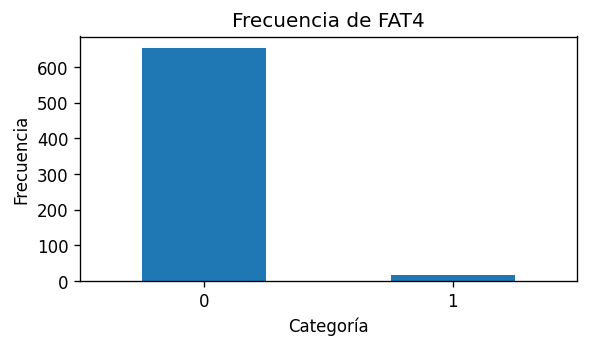
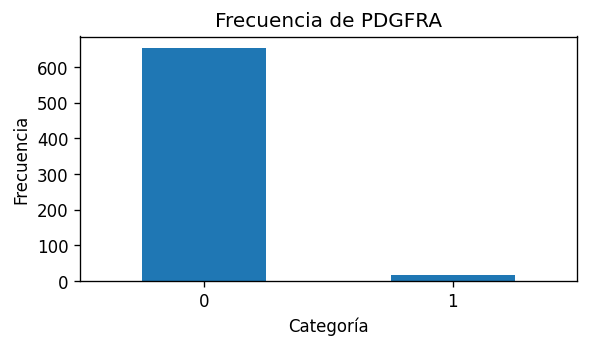

In [99]:
variables_categoricas = train_data.select_dtypes(
    include=["category"]
).columns.drop(["Grade", "Gender", "Race"])

bloques = []

for variable in variables_categoricas:

    # Tabla de frecuencias
    tabla = (
        train_data[variable]
        .value_counts(dropna=False)
        .rename_axis("Categoría")
        .reset_index(name="Frecuencia")
    )

    tabla["Porcentaje"] = (
        tabla["Frecuencia"] / tabla["Frecuencia"].sum() * 100
    ).round(2)

    html_tabla = tabla.to_html(
        index=False,
        classes="tabla-categorica"
    )

    # Gráfico de barras
    frecuencias = train_data[variable].value_counts(dropna=False)

    fig, ax = plt.subplots(figsize=(5, 3))

    frecuencias.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"Frecuencia de {variable}")
    ax.set_xlabel("Categoría")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()

    buffer = io.BytesIO()
    fig.savefig(
        buffer,
        format="png",
        dpi=120,
        bbox_inches="tight"
    )
    plt.close(fig)

    imagen_base64 = base64.b64encode(
        buffer.getvalue()
    ).decode()

    bloque = f"""
    <div style="
        padding: 15px;
        border-radius: 8px;
        margin-bottom: 20px;
    ">

        <h4 style="margin-bottom: 10px;">
            {variable}
        </h4>

        <!-- FILA: TABLA -->
        <div style="
            margin-bottom: 15px;
        ">
            {html_tabla}
        </div>

        <!-- FILA: GRÁFICO -->
        <div style="
            text-align: center;
        ">
            <img
                src="data:image/png;base64,{imagen_base64}"
                style="max-width: 100%;"
            >
        </div>

    </div>
    """

    bloques.append(bloque)

html_final = f"""
<div style="
    display: grid;
    grid-template-columns: repeat(2, 1fr);
    gap: 30px;
    margin-top: 20px;
">
    {''.join(bloques)}
</div>
"""

display(HTML(html_final))

## Análisis Bivariado

En esta sección se analiza la relación entre las variables categóricas independientes y la variable objetivo `Grade`. Para cada variable se comparan las frecuencias absolutas y relativas de sus categorías dentro de cada nivel de `Grade`, con el propósito de identificar posibles diferencias en su distribución según la variable objetivo. Las comparaciones se complementan mediante gráficos de barras agrupadas, facilitando la interpretación visual de los patrones observados.

In [157]:
def analisis_bivariado(df, target, variable, etiquetas=None, 
                       titulo=None, xlabel=None, figsize=(8, 5)):

    df_plot = (
        df
        .groupby([target, variable])
        .size()
        .reset_index(name="n")
    )

    df_plot["porcentaje"] = (
        df_plot["n"] /
        df_plot.groupby(target)["n"].transform("sum") * 100
    ).round(1)

    df_plot["categoria"] = df_plot[variable]

    if etiquetas is not None:
        df_plot["categoria"] = (
            df_plot["categoria"].map(etiquetas)
        )

    df_plot = df_plot[
        [target, "categoria", "n", "porcentaje"]
    ]

    categorias = sorted(df_plot["categoria"].unique())
    grupos = sorted(df_plot[target].unique())

    x = np.arange(len(categorias))
    ancho = 0.8 / len(grupos)

    fig, ax = plt.subplots(figsize=figsize)

    for i, grupo in enumerate(grupos):

        datos = (
            df_plot[df_plot[target] == grupo]
            .set_index("categoria")
            .reindex(categorias)
        )

        posiciones = (
            x + (i - (len(grupos) - 1) / 2) * ancho
        )

        barras = ax.bar(
            posiciones,
            datos["n"],
            width=ancho,
            label=f"{target} {grupo}"
        )

        for barra, n, porcentaje in zip(
            barras,
            datos["n"],
            datos["porcentaje"]
        ):

            if not np.isnan(n):

                ax.text(
                    barra.get_x() + barra.get_width() / 2,
                    barra.get_height() + 3,
                    f"{int(n)} ({porcentaje:.1f}%)",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

    if titulo is None:
        titulo = f"Distribución de {variable} según {target}"

    if xlabel is None:
        xlabel = variable

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Cantidad de pacientes")

    ax.set_xticks(x)
    ax.set_xticklabels(categorias)

    ax.legend(title=target)

    ax.margins(y=0.12)
    plt.tight_layout()


    return df_plot, fig

### `Grade` - `Gender`

La distribución del género presenta diferencias entre los dos niveles de Grade. En Grade 0, se registran 220 hombres (56,6%) y 169 mujeres (43,4%), mientras que en Grade 1 se observan 178 hombres (63,1%) y 104 mujeres (36,9%). En ambos niveles predomina el género masculino; sin embargo, esta predominancia es mayor en Grade 1, donde los hombres representan el 63,1% frente al 56,6% en Grade 0. Por otro lado, la proporción de mujeres disminuye de 43,4% en Grade 0 a 36,9% en Grade 1. En términos descriptivos, estos resultados sugieren una mayor representación masculina en Grade 1, aunque las diferencias observadas no permiten establecer por sí solas una asociación estadísticamente significativa entre el género y Grade.

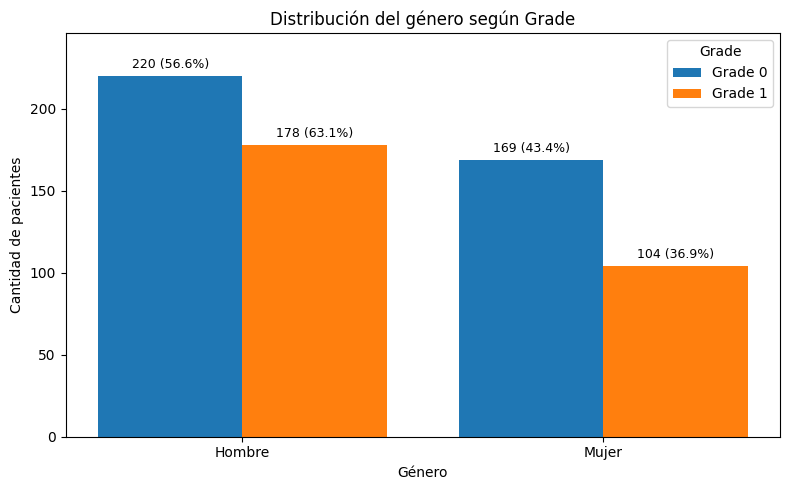

In [158]:
tabla_gender_bivariada = analisis_bivariado(
    train_data,
    target="Grade",
    variable="Gender",
    etiquetas={
        0: "Hombre",
        1: "Mujer"
    },
    titulo="Distribución del género según Grade",
    xlabel="Género"
)

### `Grade` - `Race`

La distribución por grupo racial muestra un predominio marcado de la población blanca en ambos niveles de Grade. En Grade 0, el grupo White concentra 365 pacientes (93,8%), mientras que en Grade 1 representa 246 pacientes (87,2%). El grupo Black or African American constituye el segundo grupo con mayor representación, con 16 pacientes (4,1%) en Grade 0 y 30 pacientes (10,6%) en Grade 1. Por su parte, la población asiática presenta una participación reducida, con 7 casos (1,8%) en Grade 0 y 6 casos (2,1%) en Grade 1, mientras que American Indian or Alaska Native presenta una presencia prácticamente nula, con 1 caso (0,3%) en Grade 0 y ningún caso en Grade 1**.**

En términos comparativos, se observa que la proporción del grupo White disminuye en Grade 1, pasando de 93,8% a 87,2%, mientras que el grupo Black or African American aumenta de 4,1% a 10,6%.

Adem'as, si bien existen diferencias en la distribución de los grupos raciales entre los niveles de Grade, estos resultados deben analizarse con precaución, ya que la muestra está fuertemente concentrada en el grupo White y algunas de las demás categorías presentan muy pocas observaciones.

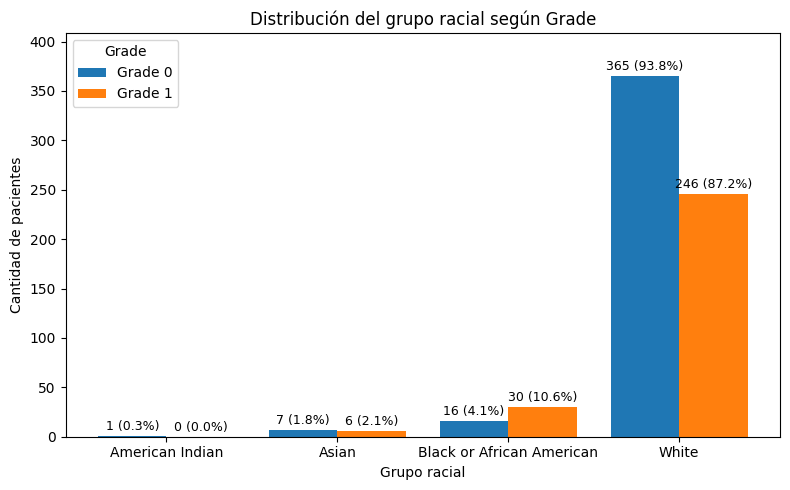

In [159]:
tabla_race_bivariada = analisis_bivariado(
    train_data,
    target="Grade",
    variable="Race",
    etiquetas={
        0: "White",
        1: "Black or African American",
        2: "Asian",
        3: "American Indian"
    },
    titulo="Distribución del grupo racial según Grade",
    xlabel="Grupo racial"
)

### `Grade` - `variables genéticas`

Se analiza la distribución de las variables genéticas según los niveles de Grade, diferenciando entre pacientes con glioma de bajo grado (LGG, Grade 0) y glioblastoma (GBM, Grade 1). Esta comparación permite identificar diferencias descriptivas en la presencia o ausencia de mutaciones entre ambos grupos.

In [160]:
def crear_menu_gen(
    df,
    target,
    variable,
    interpretacion,
    etiquetas=None,
    figsize=(7, 4)
):

    df_plot, fig = analisis_bivariado(
        df=df,
        target=target,
        variable=variable,
        etiquetas=etiquetas,
        figsize=figsize
    )

    buffer = io.BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=120,
        bbox_inches="tight"
    )

    plt.close(fig)

    imagen_base64 = base64.b64encode(
        buffer.getvalue()
    ).decode()


    html = f"""
    <details style="
        margin: 10px 0;
        border: 1px solid #d0d7de;
        border-radius: 8px;
        overflow: hidden;
    ">

        <summary style="
            padding: 14px 18px;
            cursor: pointer;
            font-size: 17px;
            font-weight: 500;
            background-color: var(--pst-color-surface);
            color: var(--pst-color-text-base);
        ">
            {variable}
        </summary>

        <div style="
            padding: 20px;
        ">

            <p style="
                line-height: 1.7;
                text-align: justify;
                margin-top: 0;
            ">
                {interpretacion}
            </p>

            <div style="
                text-align: center;
                margin-top: 20px;
            ">

                <img
                    src="data:image/png;base64,{imagen_base64}"
                    style="
                        max-width: 100%;
                        height: auto;
                    "
                >

            </div>

        </div>

    </details>
    """

    return html

In [170]:
# Gen IDH1
html_idh1 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="IDH1",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    Al comparar la presencia de la mutación en IDH1 entre los dos niveles de Grade, 
    se observa una diferencia bastante marcada. En los LGG (Grade 0), 303 pacientes (77,9%) 
    presentan la mutación de IDH1, mientras que 86 pacientes (22,1%) no presentan la mutación. 
    En contraste, en los GBM (Grade 1), solamente 19 pacientes (6,7%) presentan la mutación, 
    mientras que 263 pacientes (93,3%) no la presentan.

    Esto muestra un patrón muy marcado donde la mutación de IDH1 es mucho más frecuente en 
    los LGG que en los GBM. En los LGG, aproximadamente 8 de cada 10 pacientes presentan la 
    mutación, mientras que en los GBM ocurre en aproximadamente 7 de cada 100 pacientes.
    Por el contrario, la ausencia de la mutación predomina ampliamente en los GBM.

    Desde una perspectiva descriptiva, estos resultados sugieren que la presencia de la mutación 
    IDH1 está fuertemente asociada con los LGG en este conjunto de datos, mientras que su ausencia 
    caracteriza en mayor proporción a los GBM.
    """
)



# Gen TP53
html_tp53 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="TP53",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    Al comparar la presencia de la mutación en TP53 entre los dos niveles de Grade, se observa una
    diferencia en su distribución. En los LGG (Grade 0), 177 pacientes (45,5 %) presentan la mutación
    de TP53, mientras que 212 pacientes (54,5 %) no la presentan. En contraste, en los GBM (Grade 1),
    93 pacientes (33,0 %) presentan la mutación, mientras que 189 pacientes (67,0 %) no presentan la mutación.

    Estos resultados muestran que la ausencia de la mutación TP53 predomina en ambos grupos, aunque es más
    frecuente en los GBM. En los LGG, aproximadamente 5 de cada 10 pacientes presentan la mutación,
    mientras que en los GBM la presentan aproximadamente 3 de cada 10 pacientes. Por otro lado, la presencia 
    de TP53 es relativamente mayor en los LGG que en los GBM.
    """
)



# Gen ATRX
html_atrx = crear_menu_gen(
    train_data,
    target="Grade",
    variable="ATRX",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La gráfica muestra una diferencia clara en la distribución de la mutación de ATRX entre los dos grados 
    de glioma. En el Grado 0, la ausencia de mutación de ATRX es mayoritaria ya que se observa en 242 pacientes 
    (62,2%), mientras que la presencia de la mutación aparece en 147 pacientes (37,8%).

    En contraste, en el Grado 1, la ausencia de mutación deATRX es todavía más predominante, con 257 pacientes (91,1%), 
    mientras que únicamente 25 pacientes (8,9%) presentan la mutación.

    Esto indica que la presencia de una mutación en ATRX está considerablemente más representada en el Grado 0 que 
    en el Grado 1. En términos relativos, la mutación aparece en el 37,8% de los pacientes de Grado 0 frente al 8,9% 
    de los pacientes de Grado 1. Por tanto, existe una diferencia importante en la distribución de ATRX entre ambas clases.
    """
)



# Gen PTEN
html_pten = crear_menu_gen(
    train_data,
    target="Grade",
    variable="PTEN",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En la gráfica, para el Grado 0, la ausencia de mutación en PTEN es predominante, con 369 pacientes (94,9%), mientras que 
    únicamente 20 pacientes (5,1%) presentan la mutación. En cambio, en el Grado 1, aunque la ausencia continúa siendo 
    mayoritaria, su proporción disminuye considerablemente hasta 189 pacientes (67,0%), mientras que la presencia de la 
    mutación aumenta hasta 93 pacientes (33,0%).

    Por lo tanto, se observa que la mutación de PTEN está considerablemente más representada en el Grado 1. Comparando las 
    proporciones, la presencia de PTEN pasa de 5,1% en Grado 0 a 33,0% en Grado 1, lo que representa una diferencia de 27,9 
    puntos porcentuales.
    """
)



# Gen EGFR
html_egfr = crear_menu_gen(
    train_data,
    target="Grade",
    variable="EGFR",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En el Grado 0, la ausencia de mutación de EGFR es predominante, con 366 pacientes (94,1%), mientras que solo 
    23 pacientes (5,9%) presentan la mutación. Para el Grado 1, la ausencia también es mayoritaria, pero disminuye 
    a 227 pacientes (80,5%), mientras que la presencia de la mutación aumenta a 55 pacientes (19,5%).

    Por lo tanto, se observa que la presencia de la mutación en EGFR es más frecuente en el Grado 1. La proporción 
    de pacientes con EGFR mutado pasa de 5,9% en el Grado 0 a 19,5% en el Grado 1, lo que representa un incremento de 
    13,6 puntos porcentuales.
    """
)



# Gen CIC
html_cic = crear_menu_gen(
    train_data,
    target="Grade",
    variable="CIC",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    Para el caso del gen CIC, en el Grado 0, la ausencia de mutación es mayoritaria, con 300 pacientes (77,1%), mientras que 89 pacientes (22,9%) 
    presentan la mutación. En el Grado 1, la ausencia de mutación aumenta considerablemente hasta 279 pacientes (98,9%), 
    mientras que solamente 3 pacientes (1,1%) presentan una mutación en CIC.

    Por tanto, la presencia de la mutación en CIC es mucho más frecuente en el Grado 0. La proporción disminuye de 22,9% 
    en el Grado 0 a apenas 1,1% en el Grado 1, lo que representa una diferencia de 21,8 puntos porcentuales.

    Este comportamiento resulta especialmente interesante para el análisis de clasificación, ya que la distribución de 
    CIC cambia considerablemente entre las dos clases. En particular, la presencia de mutación en CIC parece estar asociada con el 
    Grado 0, mientras que su ausencia está presente en prácticamente todos los pacientes de Grado 1. Esto sugiere que CIC 
    podría ser una variable con un alto poder discriminativo para diferenciar ambas categorías.
    """
)



# Gen MUC16
html_muc16 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="MUC16",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La gráfica muestra la distribución de la mutación de MUC16 en los pacientes de Grado 0 y Grado 1. En ambos grupos 
    predomina la ausencia de la mutación, aunque se observa una diferencia en la proporción de pacientes
    que presentan la alteración.

    En el Grado 0, la ausencia corresponde a 358 pacientes (92,0%), mientras que 31 pacientes (8,0%) presentan 
    la mutación. En el Grado 1, la ausencia se presenta en 239 pacientes (84,8%), mientras que 43 pacientes (15,2%) 
    presentan la mutación.

    Por tanto, la presencia de la mutación de MUC16 es más frecuente en el Grado 1. La proporción aumenta de 8,0% en el 
    Grado 0 a 15,2% en el Grado 1, lo que representa una diferencia de 7,2 puntos porcentuales.

    A diferencia de variables como PTEN o CIC, la diferencia entre ambos grados en MUC16 es más moderada. Esto sugiere 
    que MUC16 podría aportar cierta información para diferenciar las clases, pero su capacidad discriminativa individual 
    parece menor a partir de esta distribución.
    """
)



# Gen PIK3CA
html_pik3ca = crear_menu_gen(
    train_data,
    target="Grade",
    variable="PIK3CA",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de PIK3CA es bastante similar entre los dos grupos de Grade. La ausencia de la alteración es 
    predominante tanto en Grade 0 (92,3 %) como en Grade 1 (90,4 %), mientras que su presencia representa únicamente 
    el 7,7 % y 9,6 %, respectivamente. Aunque se observa una proporción ligeramente mayor de presencia de mutación de PIK3CA en 
    Grade 1, la diferencia es pequeña (1,9 puntos porcentuales). Por lo tanto, a partir de esta comparación descriptiva, 
    PIK3CA no presenta una diferencia marcada entre ambos grados.
    """
)



# Gen NF1
html_nf1 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="NF1",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de mutación de NF1 presenta una ligera diferencia entre los grupos de Grade. La presencia de mutación de NF1 es mayor en 
    Grade 1 (10,6 %) que en Grade 0 (6,7 %), mientras que la ausencia es predominante en ambos grupos. Esta diferencia 
    de 3,9 puntos porcentuales sugiere una posible mayor frecuencia de alteraciones en NF1 en los pacientes de Grade 1. 
    Sin embargo, debido a que la diferencia entre ambos grupos es relativamente pequeña y la ausencia de mutación de NF1 predomina 
    ampliamente, no se observa una separación marcada entre los grados a partir de esta variable.
    """
)



# Gen PIK3R1
html_pik3r1 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="PIK3R1",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de PIK3R1 muestra una diferencia entre los grupos de Grade. La presencia de esta alteración es mayor 
    en Grade 1 (8,5 %) que en Grade 0 (3,9 %), con una diferencia de 4,6 puntos porcentuales. Sin embargo, la ausencia de  alteración del gen
    PIK3R1 predomina claramente en ambos grupos, representando el 96,1 % de los casos en Grade 0 y el 91,5 % en Grade 1.

    Por lo tanto, aunque se observa una mayor frecuencia de presencia de PIK3R1 en Grade 1, la diferencia no es lo 
    suficientemente marcada como para observar una separación clara entre los dos grupos únicamente mediante este análisis 
    descriptivo.
    """
)



# Gen FUBP1
html_fubp1 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="FUBP1",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En términos descriptivos, FUBP1 presenta una distribución claramente diferente según el Grade. En Grade 0, la presencia de mutación
    de FUBP1 alcanza el 10,3 % de los pacientes, mientras que en Grade 1 esta proporción disminuye considerablemente hasta 
    el 0,7 %. De manera consecuente, la ausencia de la variable es predominante en ambos grupos, aunque es especialmente alta 
    en Grade 1, donde alcanza el 99,3 %. Esta diferencia de 9,6 puntos porcentuales en la presencia de FUBP1 sugiere que esta 
    variable podría estar relacionada con la clasificación del grado tumoral y podría aportar información para diferenciar 
    entre ambos grupos.
    """
)



# Gen RB1
html_rb1 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="RB1",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La gráfica muestra la distribución  de RB1 entre los dos grupos de Grade y permite observar una diferencia apreciable 
    en la frecuencia de esta variable. En Grade 0, la ausencia de mutación de RB1 representa el 98,5 % de los pacientes (383 casos), 
    mientras que únicamente el 1,5 % presenta mutación de RB1 (6 casos). Por otro lado, en Grade 1, la ausencia corresponde al 90,4 % 
    (255 casos), mientras que la presencia aumenta hasta el 9,6 % (27 casos).

    Por lo tanto, la presencia de mutación de RB1 es considerablemente más frecuente en Grade 1, donde alcanza el 9,6 %, frente al 1,5 % 
    observado en Grade 0. Esto supone una diferencia de aproximadamente 8,1 puntos porcentuales. Aunque la ausencia continúa 
    siendo la categoría predominante en ambos grupos, el aumento de la presencia de alteración del gen RB1 en Grade 1 genera una separación 
    bastante visible entre las distribuciones.
    """
)



# Gen NOTCH1
html_notch1 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="NOTCH1",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En términos descriptivos, NOTCH1 presenta una distribución claramente diferenciada según el Grade. En Grade 0, 
    el 8,5 % de los pacientes presenta mutación de NOTCH1, mientras que en Grade 1 no se observa ningún caso con presencia de 
    esta variable. Por otro lado, la ausencia de alteración de NOTCH1 es predominante en ambos grupos, aunque alcanza el 100 % 
    en Grade 1. Esta diferencia sugiere que la presencia de mutación de NOTCH1 podría estar relacionada con la clasificación del 
    grado tumoral y podría ser una característica útil para distinguir entre ambos grupos.
    """
)



# Gen BCOR
html_bcor = crear_menu_gen(
    train_data,
    target="Grade",
    variable="BCOR",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La gráfica muestra la distribución de BCOR según el Grade y, a diferencia de algunas de las variables anteriores, 
    presenta un comportamiento muy similar entre ambos grupos. En Grade 0, el 96,7 % de los pacientes presenta ausencia 
    de mutación de BCOR (376 casos), mientras que el 3,3 % presenta su presencia (13 casos). En Grade 1, la ausencia corresponde al 
    96,8 % (273 casos) y la presencia al 3,2 % (9 casos).

    Las proporciones son prácticamente iguales entre los dos grados. La presencia de alteración del gen BCOR solo difiere en 0,1 puntos 
    porcentuales, siendo ligeramente mayor en Grade 0 (3,3 %) que en Grade 1 (3,2 %). De manera similar, la ausencia 
    presenta una diferencia mínima de 0,1 puntos porcentuales. Esto indica que no existe una separación visual relevante 
    entre los grupos respecto a esta variable.
    """
)



# Gen CSMD3
html_csm3 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="CSMD3",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En términos descriptivos, CSMD3 presenta una distribución bastante similar entre los dos niveles de Grade. La presencia
    de esta variable es ligeramente mayor en Grade 1 (4,3 %) que en Grade 0 (2,8 %), mientras que la ausencia se mantiene 
    como la categoría predominante, con 95,7 % y 97,2 %, respectivamente. Aunque este comportamiento muestra una pequeña 
    diferencia entre los grupos, la magnitud de la variación es reducida, por lo que no se aprecia una separación marcada 
    entre Grade 0 y Grade 1 a partir de CSMD3.
    """
)



# Gen SMARCA4
html_smarca4 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="SMARCA4",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de SMARCA4 muestra algunas diferencias entre los dos grupos de Grade. En Grade 0, la presencia de 
    mutación de SMARCA4 se encuentra en el 4,9 % de los pacientes, mientras que en Grade 1 solamente alcanza el 1,4 %. Esto significa 
    que la presencia de esta variable es aproximadamente 3,5 puntos porcentuales mayor en Grade 0. En ambos grupos, 
    sin embargo, predomina ampliamente la ausencia de mutación de SMARCA4, especialmente en Grade 1, donde representa el 98,6 % de 
    los casos. En consecuencia, aunque se observa una tendencia hacia una mayor presencia de mutación de SMARCA4 en Grade 0, la diferencia 
    entre los grupos es moderada y no permite considerar por sí sola a esta variable como un diferenciador fuerte del grado tumoral.
    """
)



# Gen GRIN2A
html_grin2a = crear_menu_gen(
    train_data,
    target="Grade",
    variable="GRIN2A",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En general, los datos muestran que la presencia de mutación de GRIN2A es más frecuente en los pacientes de Grade 1 que en los 
    de Grade 0, mientras que la ausencia predomina ampliamente en ambos grupos. La diferencia de 3,7 puntos porcentuales 
    sugiere una posible relación entre alteración del gen GRIN2A y el grado tumoral, aunque la baja frecuencia de presencia de esta variable 
    hace que la diferencia deba interpretarse con cautela. Por ello, será necesario comprobar mediante pruebas estadísticas 
    si esta variación es significativa y determinar posteriormente si GRIN2A aporta información útil para la clasificación 
    del Grade dentro del modelo de machine learning.
    """
)



# Gen IDH2
html_idh2 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="IDH2",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de IDH2 muestra una diferencia bastante marcada entre los dos grupos de Grade. En Grade 0, la presencia 
    de mutación de IDH2 corresponde al 4,9 % de los pacientes (19 casos), mientras que en Grade 1 solamente se presenta en el 0,7 % 
    (2 casos). Por el contrario, la ausencia de esta variable es muy elevada en ambos grupos, aunque es ligeramente mayor 
    en Grade 1, donde alcanza el 99,3 %, frente al 95,1 % observado en Grade 0.

    La diferencia en la presencia de IDH2 es de 4,2 puntos porcentuales, lo que indica que esta característica aparece 
    con mayor frecuencia en Grade 0. Además, la distribución resulta especialmente interesante porque en Grade 1 
    prácticamente todos los pacientes presentan ausencia de alteracaión en el gen IDH2.
    """
)



# Gen FAT4
html_fat4 = crear_menu_gen(
    train_data,
    target="Grade",
    variable="FAT4",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    En este caso, FAT4 presenta un comportamiento muy similar en los dos niveles de Grade. La presencia de esta variable 
    representa el 2,3 % de los casos en Grade 0 y aumenta ligeramente hasta el 3,2 % en Grade 1, mientras que la ausencia 
    se mantiene por encima del 96 % en ambos grupos. La diferencia de solo 0,9 puntos porcentuales indica que no existe 
    una separación clara entre los grados a partir de esta variable. Por lo tanto, FAT4 parece presentar una capacidad 
    discriminativa reducida por sí sola en este análisis bivariado.
    """
)



# Gen PDGFRA
html_pdgfra = crear_menu_gen(
    train_data,
    target="Grade",
    variable="PDGFRA",

    etiquetas={
        0: "Ausencia",
        1: "Presencia"
    },

    interpretacion="""
    La distribución de PDGFRA presenta una diferencia apreciable entre los dos grupos de Grade. En Grade 0, la presencia de mutación
    de PDGFRA corresponde al 1,5 % de los pacientes (6 casos), mientras que en Grade 1 aumenta hasta el 4,3 % (12 casos). 
    
    Por otro lado, la ausencia de mutación de PDGFRA continúa siendo la categoría predominante en ambos grupos, con un 98,5 % 
    en Grade 0 y un 95,7 % en Grade 1. Esto representa una diferencia de 2,8 puntos porcentuales en la presencia de mutación de PDGFRA 
    entre ambos grados. Aunque la presencia de la variable sigue siendo poco frecuente, se observa una tendencia hacia una 
    mayor proporción en Grade 1. Por tanto, a diferencia de variables como FAT4, donde las proporciones eran prácticamente 
    iguales, PDGFRA muestra una separación algo más evidente entre los grupos.
    """
)


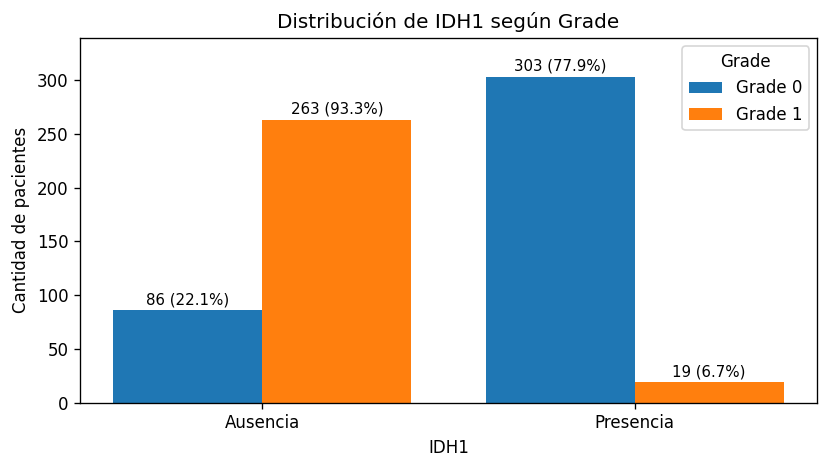
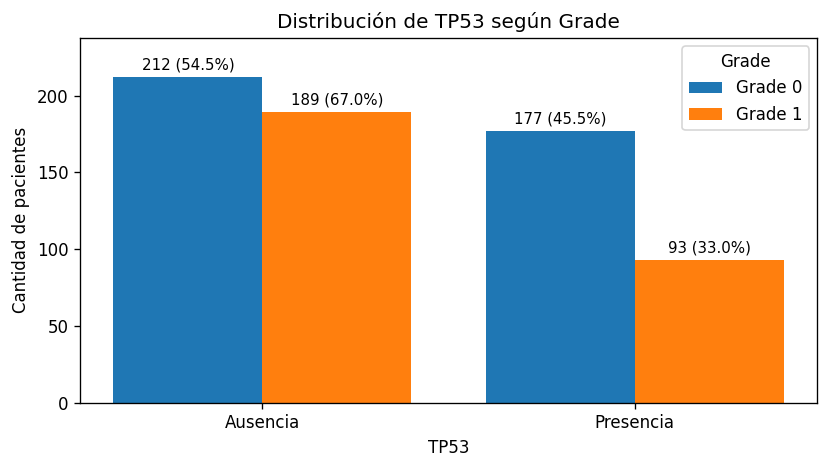
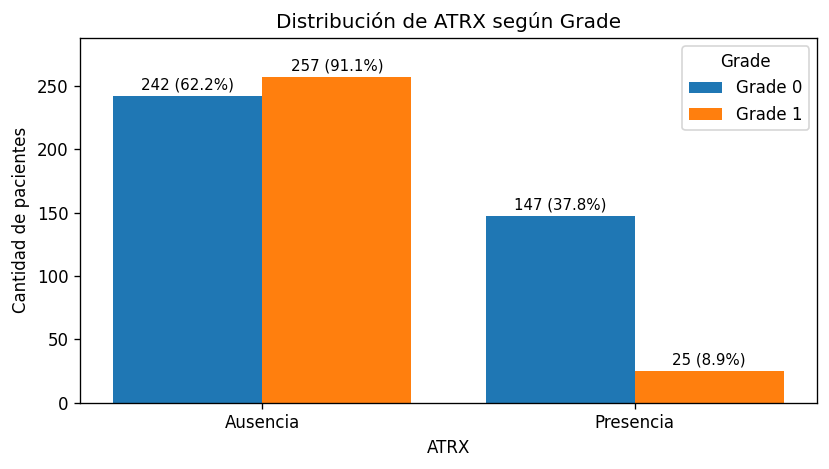
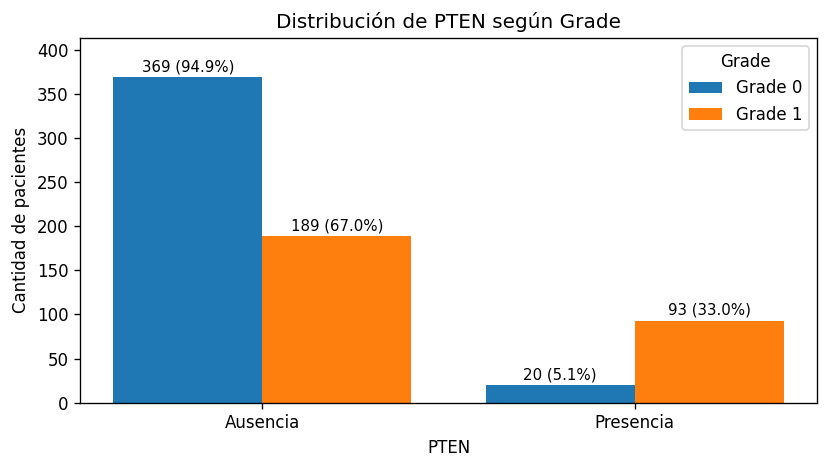
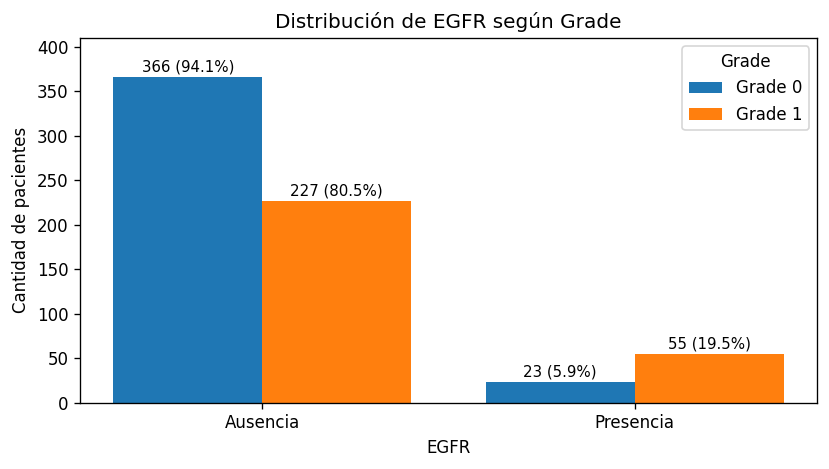
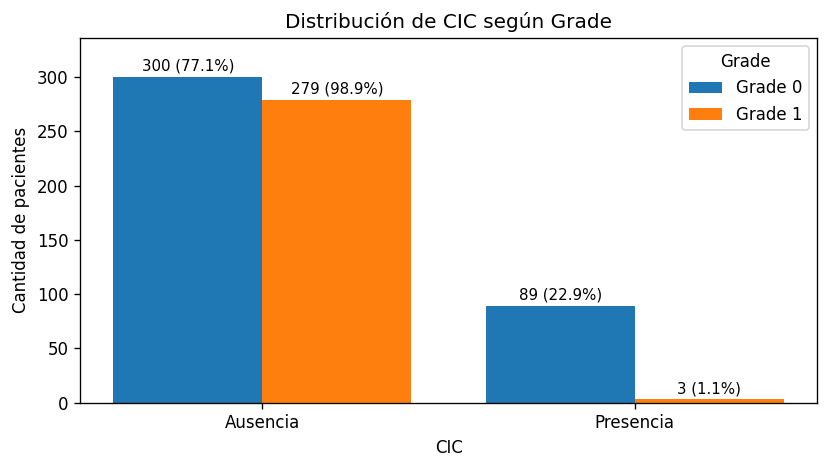
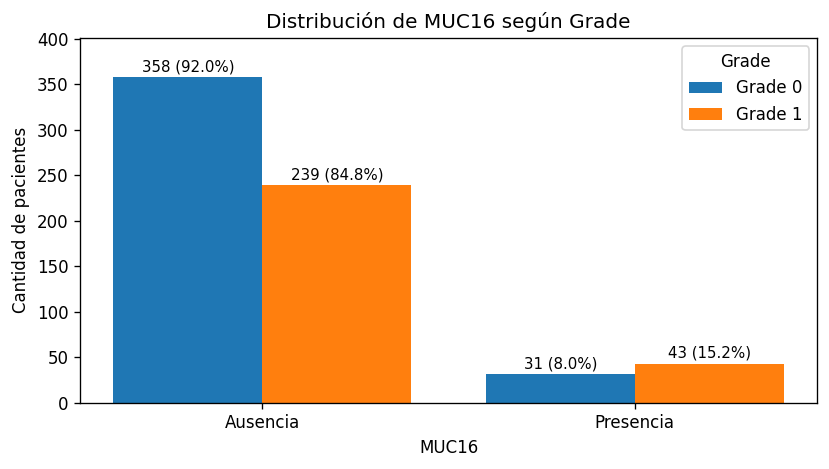
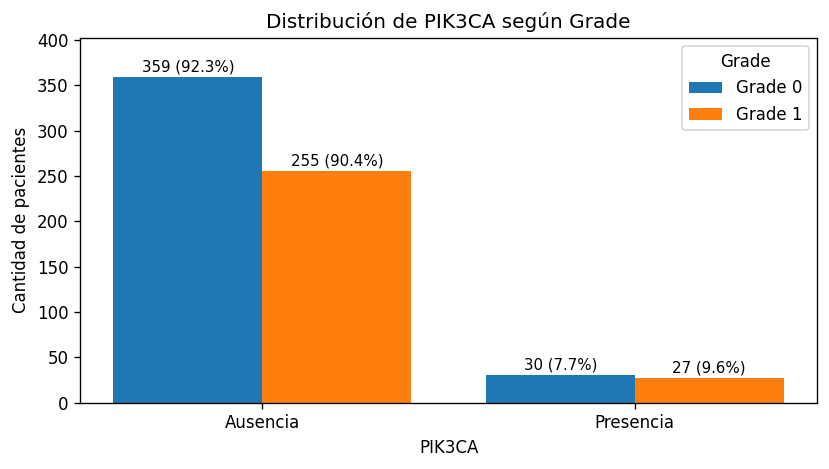
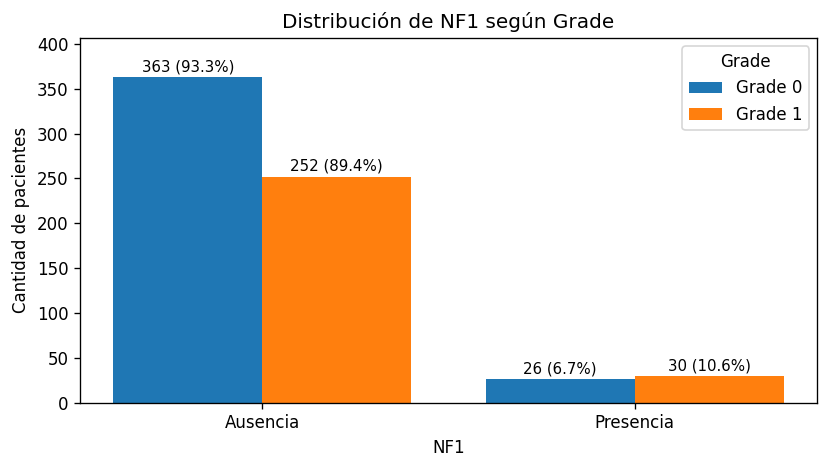
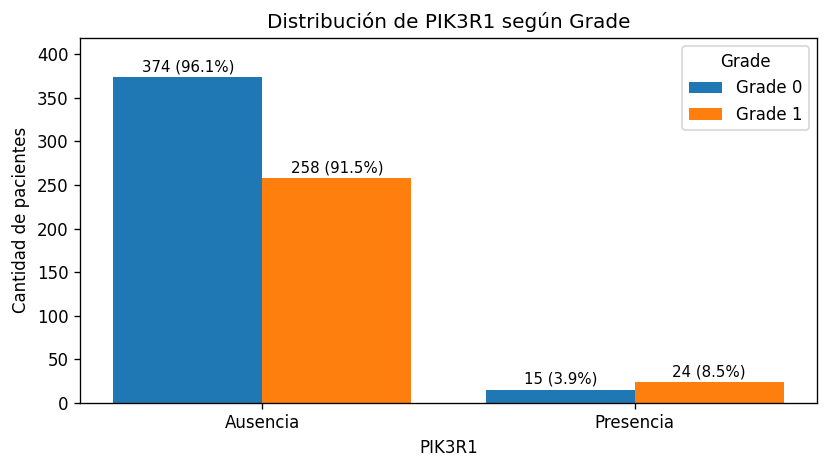
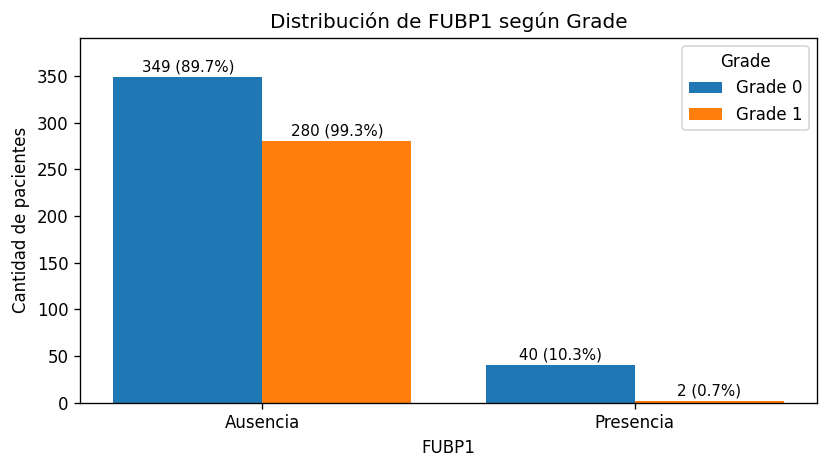
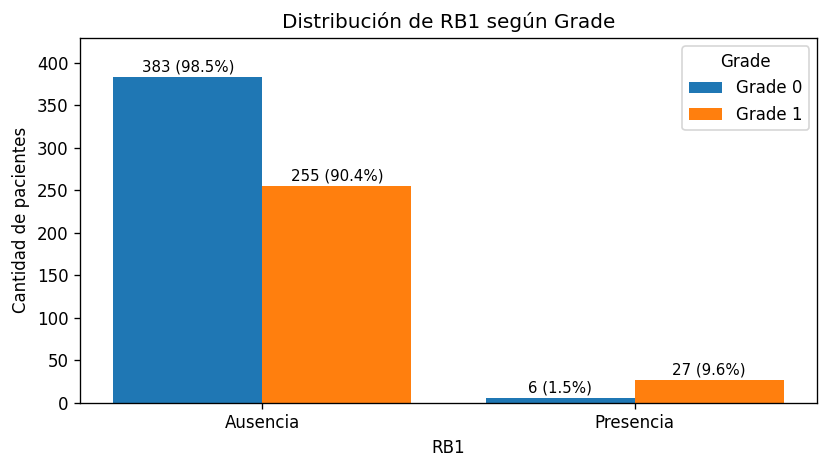
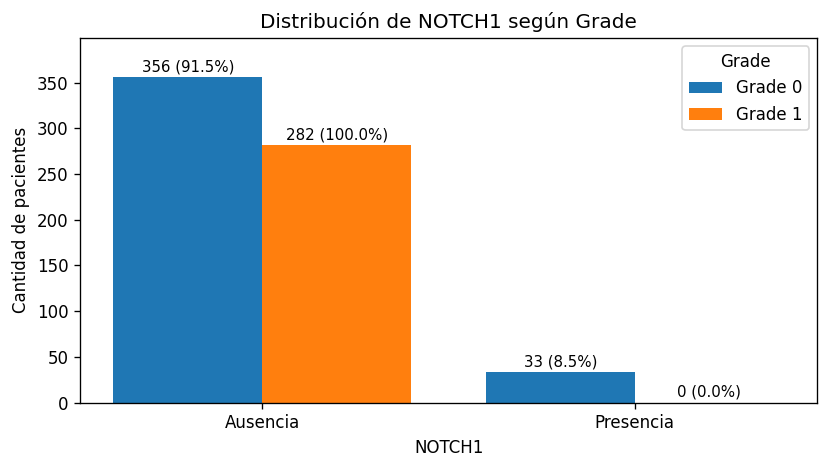
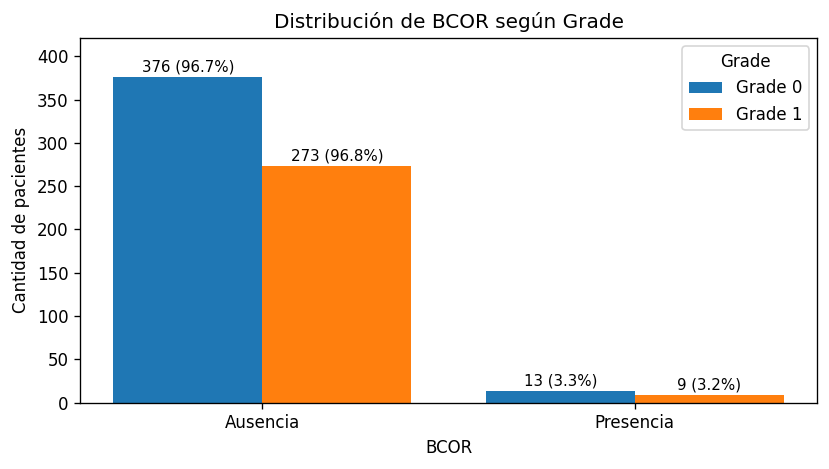
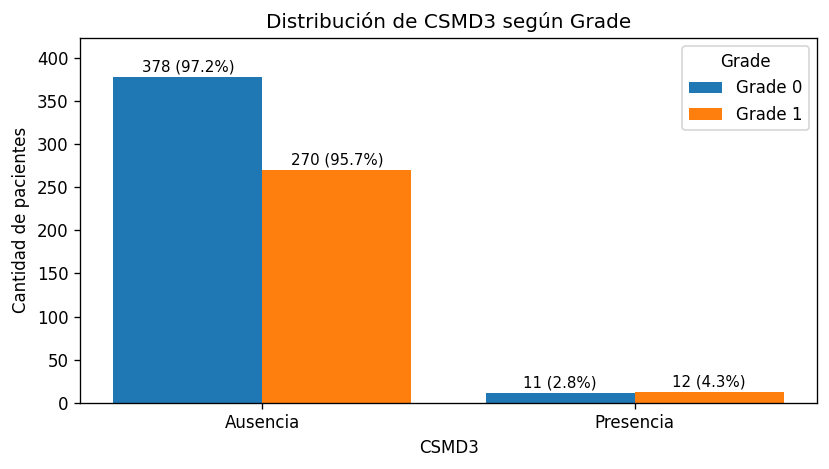
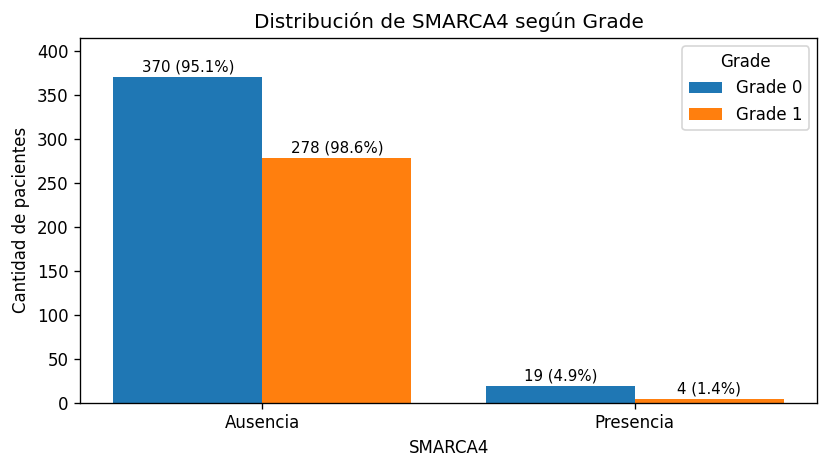
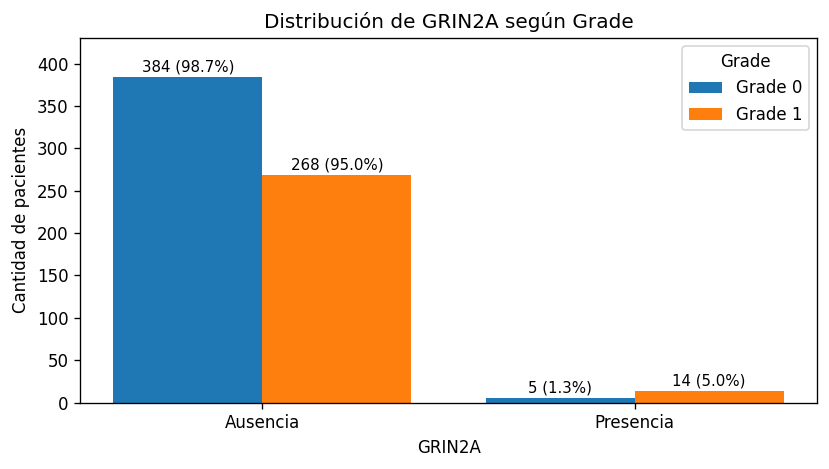
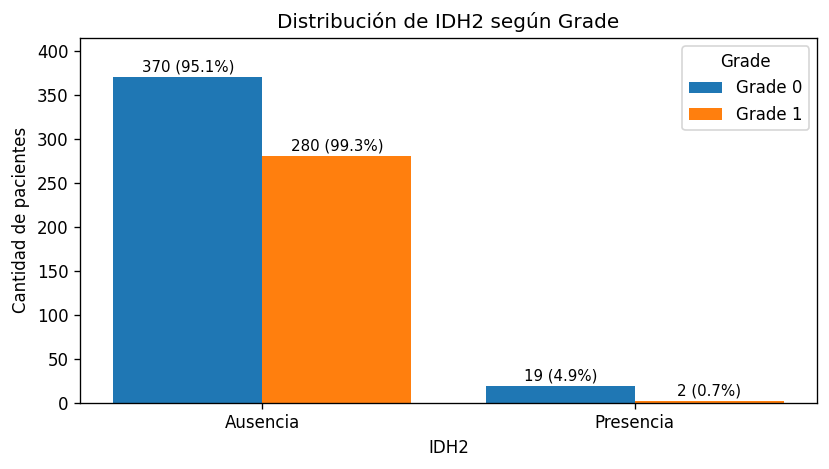
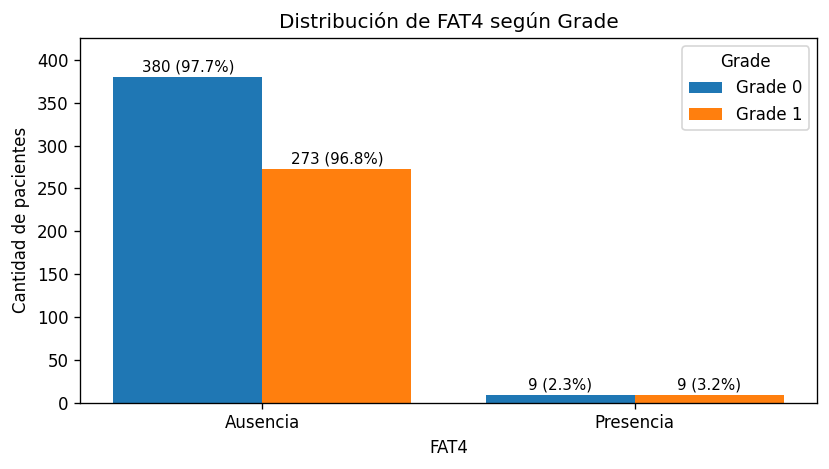
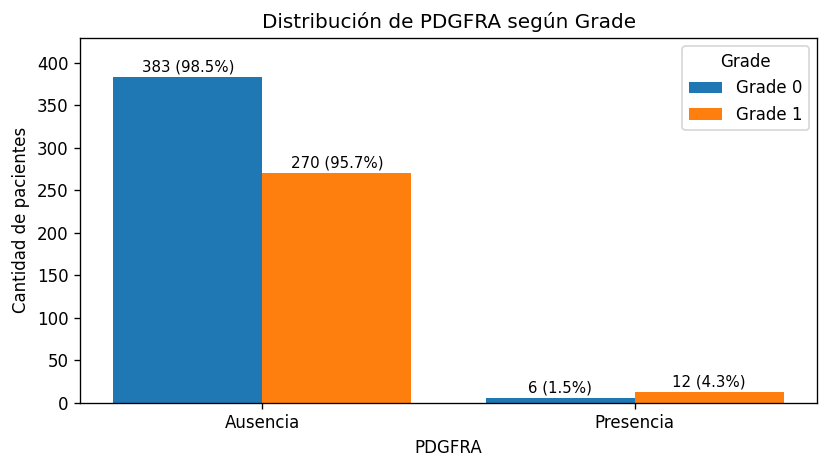

In [171]:
html_genes = f"""
<div style="
    margin-top: 20px;
">

    {html_idh1}
    {html_tp53}
    {html_atrx}
    {html_pten}
    {html_egfr}
    {html_cic}
    {html_muc16}
    {html_pik3ca}
    {html_nf1}
    {html_pik3r1}
    {html_fubp1}
    {html_rb1}
    {html_notch1}
    {html_bcor}
    {html_csm3}
    {html_smarca4}
    {html_grin2a}
    {html_idh2}
    {html_fat4}
    {html_pdgfra}

</div>
"""

display(HTML(html_genes))

There is a lot more that you can do with outputs (such as including interactive outputs)
with your book. For more information about this, see [the Jupyter Book documentation](https://jupyterbook.org)